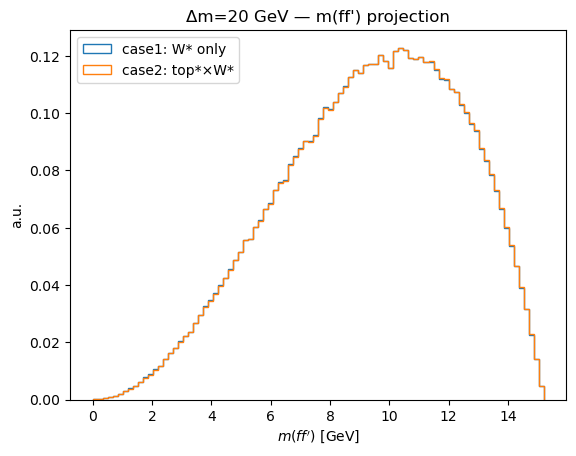

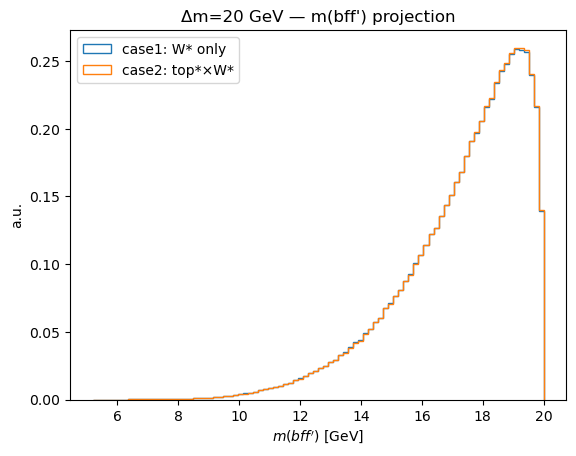

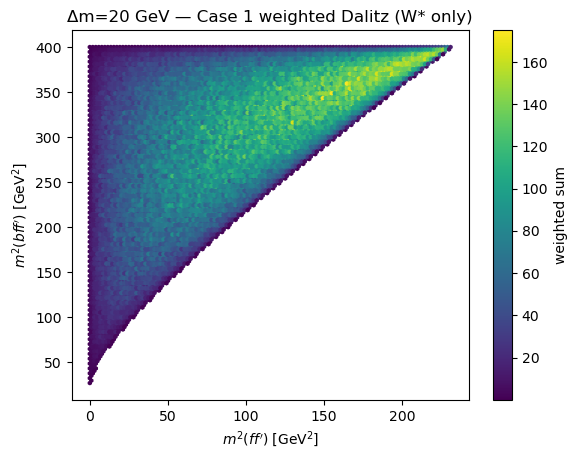

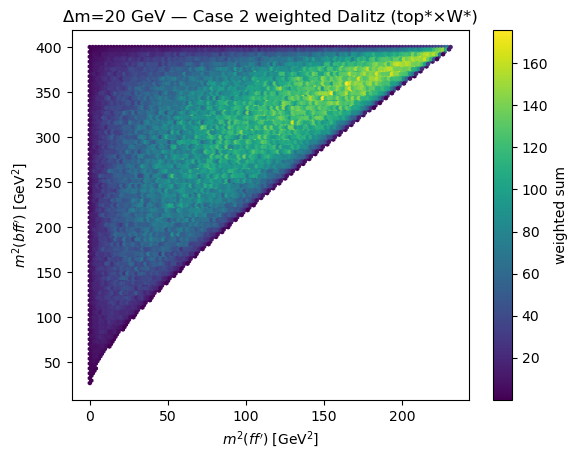

Δm=20 GeV: m(ff') max ≈ 15.2 GeV ; m(bff') max ≈ 20.0 GeV
  case1 weight spread (min/max): 7.262e-07/1.884e+00
  case2 weight spread (min/max): 7.309e-07/1.882e+00
  mean m(ff')  case1=9.33 GeV ; case2=9.34 GeV
  mean m(bff') case1=17.33 GeV ; case2=17.34 GeV



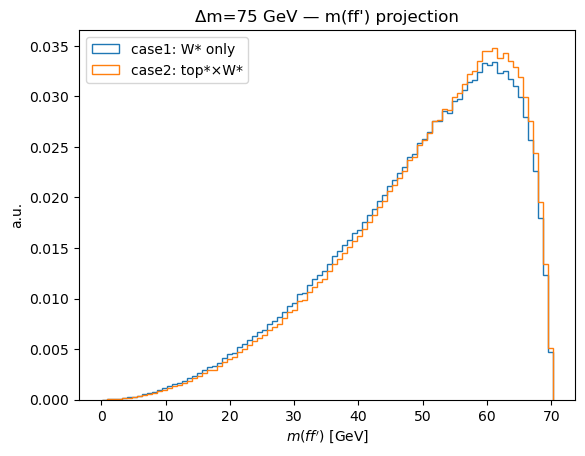

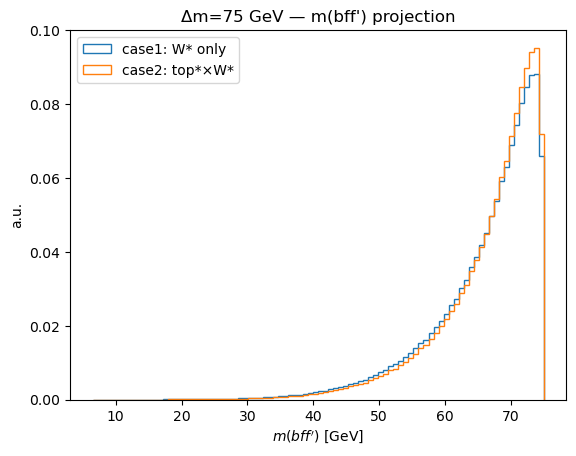

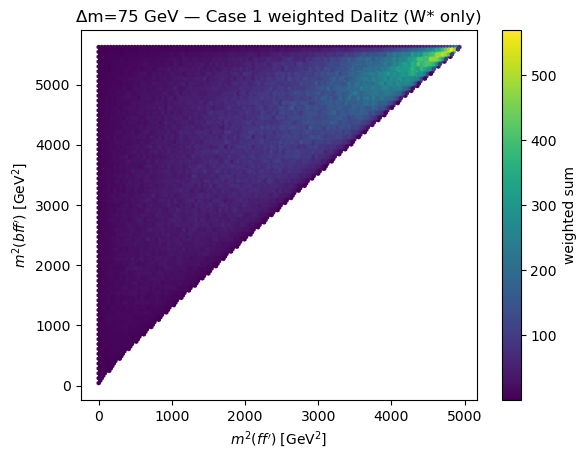

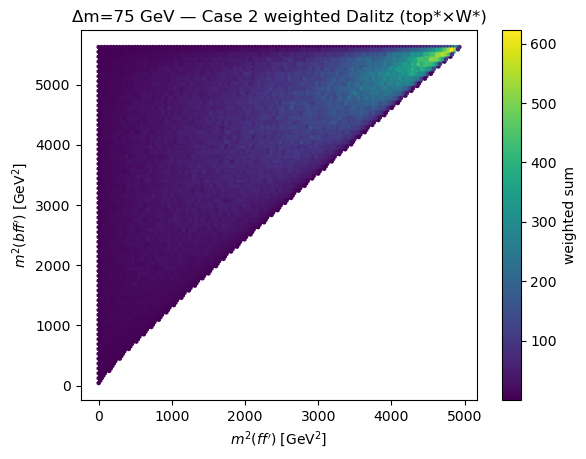

Δm=75 GeV: m(ff') max ≈ 70.2 GeV ; m(bff') max ≈ 75.0 GeV
  case1 weight spread (min/max): 1.867e-07/1.749e+00
  case2 weight spread (min/max): 2.049e-07/1.813e+00
  mean m(ff')  case1=49.67 GeV ; case2=50.32 GeV
  mean m(bff') case1=66.02 GeV ; case2=66.58 GeV



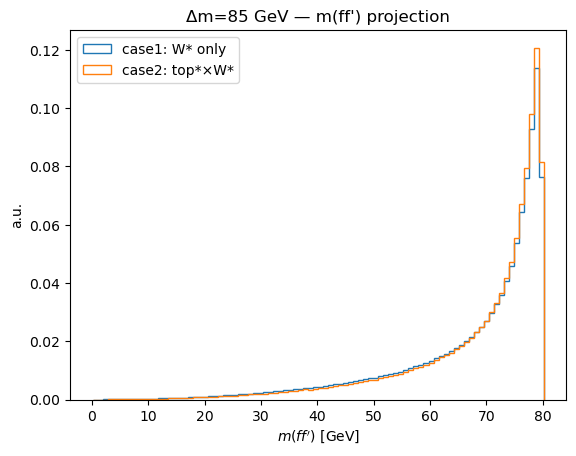

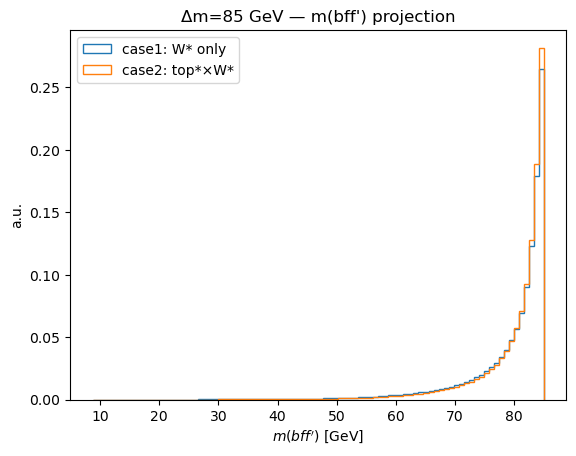

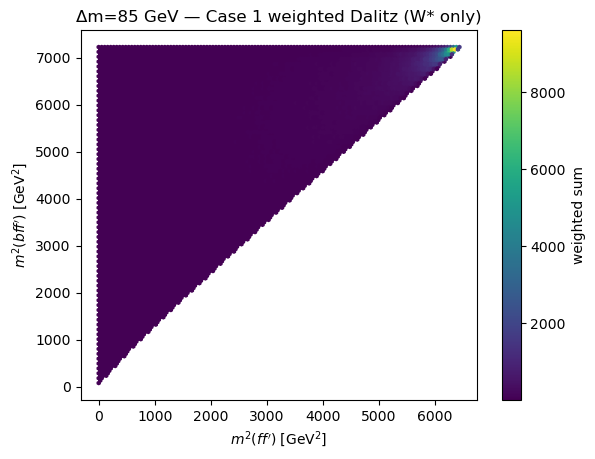

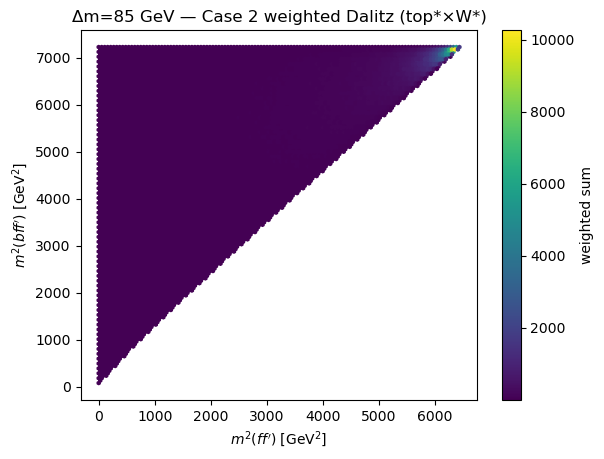

Δm=85 GeV: m(ff') max ≈ 80.2 GeV ; m(bff') max ≈ 85.0 GeV
  case1 weight spread (min/max): 6.672e-04/5.991e+00
  case2 weight spread (min/max): 4.629e-04/6.370e+00
  mean m(ff')  case1=67.89 GeV ; case2=68.71 GeV
  mean m(bff') case1=79.52 GeV ; case2=80.05 GeV



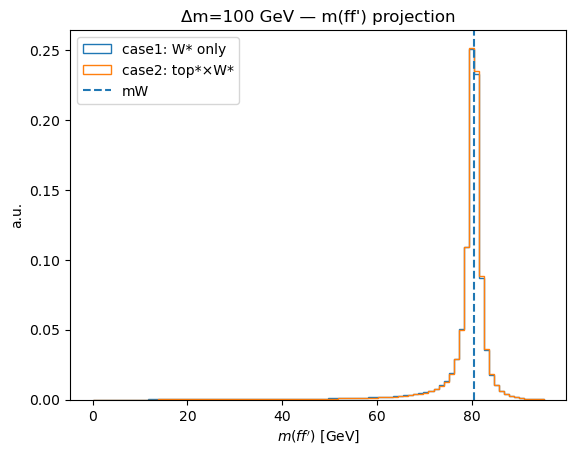

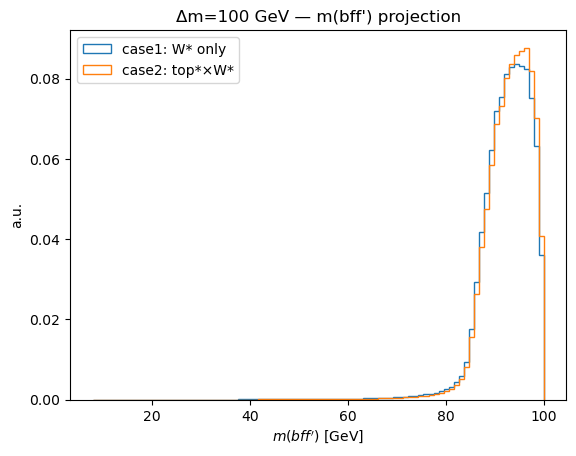

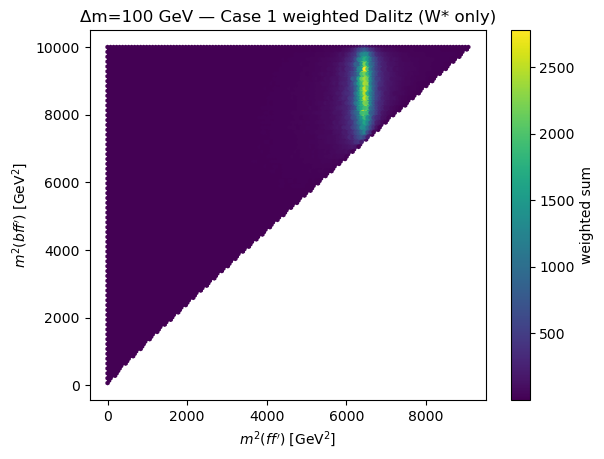

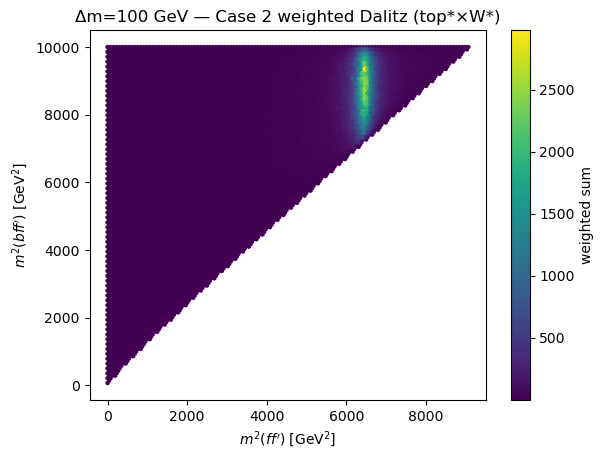

Δm=100 GeV: m(ff') max ≈ 95.2 GeV ; m(bff') max ≈ 100.0 GeV
  case1 weight spread (min/max): 1.172e-06/2.287e+01
  case2 weight spread (min/max): 1.340e-06/2.345e+01
  mean m(ff')  case1=78.89 GeV ; case2=79.08 GeV
  mean m(bff') case1=92.50 GeV ; case2=92.87 GeV



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 4-vector utilities
# -------------------------
def m2_batch(p4):
    return p4[:, 0] ** 2 - np.sum(p4[:, 1:] ** 2, axis=1)

def mass_vec(p):
    return np.sqrt(max(float(p[0] ** 2 - np.dot(p[1:], p[1:])), 0.0))

def two_body_p(M, m1, m2):
    if M < m1 + m2:
        return 0.0
    lam = (M * M - (m1 + m2) ** 2) * (M * M - (m1 - m2) ** 2)
    return np.sqrt(max(lam, 0.0)) / (2.0 * M)

def rand_unit(rng):
    z = rng.uniform(-1.0, 1.0)
    phi = rng.uniform(0.0, 2.0 * np.pi)
    r = np.sqrt(1.0 - z * z)  # non-negative by construction
    return np.array([r * np.cos(phi), r * np.sin(phi), z], float)

def boost(p, beta):
    b2 = float(np.dot(beta, beta))
    if b2 < 1e-16:
        return p.copy()
    g = 1.0 / np.sqrt(1.0 - b2)
    bp = float(np.dot(beta, p[1:]))
    gamma2 = (g - 1.0) / b2
    E = g * (p[0] + bp)
    spatial = p[1:] + gamma2 * bp * beta + g * p[0] * beta
    return np.array([E, *spatial], float)

def decay2(parent_p4, m1, m2, rng):
    M = mass_vec(parent_p4)
    p = two_body_p(M, m1, m2)
    # assume caller ensures allowed
    n = rand_unit(rng)
    p1_rf = np.array([np.sqrt(m1 * m1 + p * p), *(p * n)], float)
    p2_rf = np.array([np.sqrt(m2 * m2 + p * p), *(-p * n)], float)
    beta = parent_p4[1:] / parent_p4[0]
    return boost(p1_rf, beta), boost(p2_rf, beta)

def sample_m2_flat(rng, mmin, mmax, size=None):
    a, b = mmin * mmin, mmax * mmax
    return np.sqrt(rng.uniform(a, b, size=size))

# -------------------------
# Fast generator:
# sample invariants (mff, mbff) with a simple proposal,
# then assign weights for phase space + propagators.
# This avoids accept-reject and is much faster.
# -------------------------
def bw2(q2, m, gamma):
    return 1.0 / ((q2 - m * m) ** 2 + (m * gamma) ** 2)

def gen_events_with_invariants(M_stop, deltaM, n=80000, seed=1, mb=4.8, mf=0.0):
    """
    Generates kinematically valid events:
      stop -> chi + T(mbff)
      T -> b + W*(mff)
      W* -> f f'
    Returns 4-vectors + the sampled (mff, mbff) and phase-space weight factor.
    """
    rng = np.random.default_rng(seed)
    mchi = M_stop - deltaM
    stop = np.array([M_stop, 0.0, 0.0, 0.0], float)

    mff_min = 2.0 * mf
    mff_max = max(deltaM - mb, 0.0)
    if mff_max <= mff_min:
        raise ValueError("deltaM too small for ff' system")

    chi = np.zeros((n, 4))
    b   = np.zeros((n, 4))
    f1  = np.zeros((n, 4))
    f2  = np.zeros((n, 4))
    mff = np.zeros(n)
    mbff = np.zeros(n)
    wps = np.zeros(n)  # phase-space Jacobian factor

    for i in range(n):
        # propose mff
        mff_i = sample_m2_flat(rng, mff_min, mff_max)
        # given mff, mbff must be in [mb+mff, deltaM]
        lo = mb + mff_i
        hi = deltaM
        if hi <= lo:
            # try again (rare near endpoints)
            continue
        mbff_i = sample_m2_flat(rng, lo, hi)

        # build 4-vectors with isotropic 2-body decays
        chi_i, T = decay2(stop, mchi, mbff_i, rng)
        b_i, W   = decay2(T, mb, mff_i, rng)
        f1_i, f2_i = decay2(W, mf, mf, rng)

        chi[i] = chi_i; b[i] = b_i; f1[i] = f1_i; f2[i] = f2_i
        mff[i] = mff_i; mbff[i] = mbff_i

        # phase-space factor for constant ME (up to constants, and ignoring the dm^2 Jacobian
        # since we sample flat in m^2 already):
        wps[i] = (two_body_p(M_stop, mchi, mbff_i) *
                  two_body_p(mbff_i, mb, mff_i) *
                  two_body_p(mff_i, mf, mf))

    # Drop any unfilled rows (if any)
    mask = wps > 0
    return mchi, chi[mask], b[mask], f1[mask], f2[mask], wps[mask]

def plot_dalitz_weighted(mff2, mbff2, w, title):
    plt.figure()
    hb = plt.hexbin(mff2, mbff2, C=w, reduce_C_function=np.sum, gridsize=120, mincnt=1)
    plt.xlabel(r"$m^2(ff')$ [GeV$^2$]")
    plt.ylabel(r"$m^2(bff')$ [GeV$^2$]")
    plt.title(title)
    plt.colorbar(hb, label="weighted sum")
    plt.show()

def plot_proj(m, w1, w2, title, xlabel, vlines=()):
    plt.figure()
    plt.hist(m, bins=90, histtype="step", density=True, weights=w1, label="case1: W* only")
    plt.hist(m, bins=90, histtype="step", density=True, weights=w2, label="case2: top*×W*")
    for (x, lab) in vlines:
        plt.axvline(x, linestyle="--", label=lab)
    plt.xlabel(xlabel)
    plt.ylabel("a.u.")
    plt.title(title)
    plt.legend()
    plt.show()

def compare_two_cases(deltaM, n=60000):
    M_stop = 900.0
    mb = 4.8
    mf = 0.0
    mW, gW = 80.379, 2.085
    mt, gt = 172.5, 1.41

    mchi, chi, b, f1, f2, wps = gen_events_with_invariants(M_stop, deltaM, n=n, seed=int(deltaM*100)+7, mb=mb, mf=mf)

    mff2  = m2_batch(f1 + f2)
    mbff2 = m2_batch(b + f1 + f2)

    # Case weights on top of constant-ME phase space
    w_case1 = wps * bw2(mff2, mW, gW)
    w_case2 = wps * bw2(mff2, mW, gW) * bw2(mbff2, mt, gt)

    # normalize for plotting (so "density=True" makes sense)
    w_case1 /= np.mean(w_case1)
    w_case2 /= np.mean(w_case2)

    # Projections
    mff = np.sqrt(np.maximum(mff2, 0.0))
    mbff = np.sqrt(np.maximum(mbff2, 0.0))

    v1 = []
    if (deltaM - mb) > mW:
        v1.append((mW, "mW"))
    v2 = []
    if deltaM > mt:
        v2.append((mt, "mt"))

    plot_proj(mff, w_case1, w_case2,
              title=f"Δm={deltaM:.0f} GeV — m(ff') projection",
              xlabel=r"$m(ff')$ [GeV]",
              vlines=v1)

    plot_proj(mbff, w_case1, w_case2,
              title=f"Δm={deltaM:.0f} GeV — m(bff') projection",
              xlabel=r"$m(bff')$ [GeV]",
              vlines=v2)

    # Dalitz for key regions only
    # if deltaM in (100.0, 200.0):
    plot_dalitz_weighted(mff2, mbff2, w_case1, f"Δm={deltaM:.0f} GeV — Case 1 weighted Dalitz (W* only)")
    plot_dalitz_weighted(mff2, mbff2, w_case2, f"Δm={deltaM:.0f} GeV — Case 2 weighted Dalitz (top*×W*)")

    # Print quick diagnostics
    print(f"Δm={deltaM:.0f} GeV: m(ff') max ≈ {deltaM-mb:.1f} GeV ; m(bff') max ≈ {deltaM:.1f} GeV")
    print(f"  case1 weight spread (min/max): {w_case1.min():.3e}/{w_case1.max():.3e}")
    print(f"  case2 weight spread (min/max): {w_case2.min():.3e}/{w_case2.max():.3e}")
    print(f"  mean m(ff')  case1={np.average(mff, weights=w_case1):.2f} GeV ; case2={np.average(mff, weights=w_case2):.2f} GeV")
    print(f"  mean m(bff') case1={np.average(mbff, weights=w_case1):.2f} GeV ; case2={np.average(mbff, weights=w_case2):.2f} GeV\n")

# Run the three deltaM points
for dm in [20.0, 75.0, 85.0, 100.0, 168, 174, 300.0]:
    compare_two_cases(dm, n=500_000)

